In [16]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

DATA_DIR = "data"          # папка с .txt
WINDOW = 4                 # контекстное окно
MAX_VOCAB = 20000           # размер словаря (включая <UNK>)
MIN_COUNT = 2              # минимум частоты слова, чтобы попасть в словарь
EMB_DIM = 200              # размер эмбеддинга
BATCH_SIZE = 1024
EPOCHS_SG = 10              # 5-10 по ТЗ
EPOCHS_CBOW = 10           # 5-10 по ТЗ
K_NEG = 5                  # negative samples

device: cuda


Загрузка исходного теста

In [17]:
def read_all_txt(data_dir: str) -> str:
    parts = []
    txt_files = sorted(Path(data_dir).rglob("*.txt"))
    for p in txt_files:
        parts.append(p.read_text(encoding="utf-8", errors="ignore"))
    return "\n".join(parts), txt_files

text, txt_files = read_all_txt(DATA_DIR)

print("txt_files:", len(txt_files))
print("chars:", len(text))
print("preview:", text[:200].replace("\n", " "))

txt_files: 1
chars: 952801
preview: this tale grew in the telling until it became a history of the great war of the ring and included many glimpses of the yet more ancient history that preceded it it was begun soon after the hobbit was 


# Задание 2
сегментируем текст на фрагменты.

In [18]:
_WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def split_sentences(text: str) -> list[str]:
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    # если есть нормальная пунктуация — режем по ней
    if any(ch in text for ch in ".!?"):
        parts = re.split(r"[.!?]+", text)
        parts = [p.strip() for p in parts if p.strip()]
        if len(parts) >= 100:
            return parts

    # иначе режем по строкам
    lines = []
    for line in text.split("\n"):
        s = line.strip()
        if s:
            lines.append(s)
    return lines

def tokenize(s: str) -> list[str]:
    return _WORD_RE.findall(s.lower())

sentences = split_sentences(text)
tokenized = [tokenize(s) for s in sentences]
tokenized = [s for s in tokenized if len(s) >= 3]   # выкидываем слишком короткие

total_tokens = sum(len(s) for s in tokenized)
freqs = Counter(t for s in tokenized for t in s)

print("sentences:", len(sentences))
print("tokenized_sentences:", len(tokenized))
print("total_tokens:", total_tokens)
print("raw_vocab_size:", len(freqs))
print("example:", tokenized[0][:25])
print("top10:", freqs.most_common(10))

sentences: 14601
tokenized_sentences: 14117
total_tokens: 186836
raw_vocab_size: 8658
example: ['this', 'tale', 'grew', 'in', 'the', 'telling', 'until', 'it', 'became', 'a', 'history', 'of', 'the', 'great', 'war', 'of']
top10: [('the', 11596), ('and', 7498), ('of', 5023), ('to', 3905), ('a', 3689), ('he', 2990), ('in', 2975), ('i', 2722), ('it', 2713), ('that', 2486)]


In [19]:
def build_vocab(tokenized_sentences, max_vocab=5000, min_count=2):
    cnt = Counter(t for s in tokenized_sentences for t in s)
    items = [(w, c) for w, c in cnt.items() if c >= min_count]
    items.sort(key=lambda x: x[1], reverse=True)

    vocab = ["<UNK>"] + [w for w, _ in items[:max(0, max_vocab - 1)]]
    word2id = {w: i for i, w in enumerate(vocab)}
    id2word = {i: w for w, i in word2id.items()}
    return vocab, word2id, id2word

vocab, word2id, id2word = build_vocab(tokenized, MAX_VOCAB, MIN_COUNT)

tokenized_v = []
unk = "<UNK>"
for s in tokenized:
    tokenized_v.append([w if w in word2id else unk for w in s])

unk_tokens = sum(1 for s in tokenized_v for w in s if w == unk)
total_tokens_v = sum(len(s) for s in tokenized_v)

print("vocab_size:", len(vocab))
print("UNK_id:", word2id["<UNK>"])
print("unk_tokens:", unk_tokens, "| share:", unk_tokens / total_tokens_v)
print("mapped example:", tokenized_v[0][:25])
print("top10_vocab:", vocab[:10])

vocab_size: 5318
UNK_id: 0
unk_tokens: 3341 | share: 0.017881992763707208
mapped example: ['this', 'tale', 'grew', 'in', 'the', 'telling', 'until', 'it', 'became', 'a', 'history', 'of', 'the', 'great', 'war', 'of']
top10_vocab: ['<UNK>', 'the', 'and', 'of', 'to', 'a', 'he', 'in', 'i', 'it']


Формирование словаря

In [20]:
import random
from collections import Counter

def subsample(tokenized_v, t=1e-5):
    cnt = Counter(w for s in tokenized_v for w in s)
    total = sum(cnt.values())
    freqs = {w: c / total for w, c in cnt.items()}

    out = []
    for s in tokenized_v:
        ns = []
        for w in s:
            f = freqs[w]
            p_drop = max(0.0, 1.0 - (t / f) ** 0.5)  # word2vec subsampling
            if random.random() > p_drop:
                ns.append(w)
        if len(ns) >= 3:
            out.append(ns)
    return out

tokenized_v = subsample(tokenized_v, t=1e-5)
print("after subsampling, sentences:", len(tokenized_v), "tokens:", sum(len(s) for s in tokenized_v))

after subsampling, sentences: 3989 tokens: 13992


In [21]:
def make_skipgram_pairs(tokenized_sentences_v, word2id, window=2):
    pairs = []
    for sent in tokenized_sentences_v:
        ids = [word2id.get(w, 0) for w in sent]  # 0 = <UNK>
        n = len(ids)
        for i, center in enumerate(ids):
            L = max(0, i - window)
            R = min(n, i + window + 1)
            for j in range(L, R):
                if j == i:
                    continue
                pairs.append((center, ids[j]))
    return np.asarray(pairs, dtype=np.int64)

pairs = make_skipgram_pairs(tokenized_v, word2id, window=WINDOW)

print("pairs.shape:", pairs.shape)
for a, b in pairs[:10]:
    print(id2word[int(a)], "->", id2word[int(b)])

pairs.shape: (37124, 2)
preceded -> soon
preceded -> was
soon -> preceded
soon -> was
was -> preceded
was -> soon
first -> set
first -> order
first -> elder
first -> days


Подготовка данных для обучения Skip-gram

In [22]:
class SkipGramPairsDataset(Dataset):
    def __init__(self, pairs_np: np.ndarray):
        self.pairs = torch.from_numpy(pairs_np)  # (N,2) int64

    def __len__(self):
        return self.pairs.shape[0]

    def __getitem__(self, idx):
        return self.pairs[idx, 0], self.pairs[idx, 1]

sg_ds = SkipGramPairsDataset(pairs)
sg_dl = DataLoader(sg_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)

print("sg batches:", len(sg_dl))

sg batches: 36


# Задание 3
Подготовка negative sampling для Skip-gram

In [23]:
V = len(vocab)

id_counts = torch.zeros(V, dtype=torch.float32)
for sent in tokenized_v:
    for w in sent:
        id_counts[word2id.get(w, 0)] += 1

neg_weights = id_counts.pow(0.75)
neg_weights[0] = 0.0  # <UNK> не берём как негатив (так чище)
neg_probs = neg_weights / neg_weights.sum()

print("V:", V, "| total_tokens:", int(id_counts.sum().item()))
print("neg_probs sum:", float(neg_probs.sum().item()))

V: 5318 | total_tokens: 13992
neg_probs sum: 1.0


Skip-gram модель

In [24]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, emb_dim)
        self.out_embed = nn.Embedding(vocab_size, emb_dim)
        nn.init.uniform_(self.in_embed.weight, -0.5/emb_dim, 0.5/emb_dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, center_ids, pos_ids, neg_ids):
        v = self.in_embed(center_ids)          # (B,D)
        u_pos = self.out_embed(pos_ids)        # (B,D)
        u_neg = self.out_embed(neg_ids)        # (B,K,D)

        pos_score = torch.sum(v * u_pos, dim=1)                 # (B,)
        pos_loss = F.logsigmoid(pos_score)                      # (B,)

        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2) # (B,K)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)          # (B,)

        return -(pos_loss + neg_loss).mean()

sg_model = SkipGramNegSampling(V, EMB_DIM).to(device)
sg_opt = torch.optim.Adam(sg_model.parameters(), lr=2e-3)

neg_probs_dev = neg_probs.to(device)

print("Skip-gram model ready")

Skip-gram model ready


In [25]:
for ep in range(1, EPOCHS_SG + 1):
    sg_model.train()
    total_loss = 0.0
    steps = 0

    for center, context in sg_dl:
        center = center.to(device)
        context = context.to(device)

        neg = torch.multinomial(
            neg_probs_dev,
            num_samples=center.shape[0] * K_NEG,
            replacement=True
        ).view(center.shape[0], K_NEG)

        sg_opt.zero_grad(set_to_none=True)
        loss = sg_model(center, context, neg)
        loss.backward()
        sg_opt.step()

        total_loss += float(loss.item())
        steps += 1

    print(f"epoch {ep}/{EPOCHS_SG} | loss={total_loss/steps:.4f}")

sg_emb = sg_model.in_embed.weight.detach().cpu().numpy()
np.save("skipgram_embeddings.npy", sg_emb)
print("saved skipgram_embeddings.npy | shape:", sg_emb.shape)

epoch 1/10 | loss=4.1462
epoch 2/10 | loss=3.6816
epoch 3/10 | loss=2.8988
epoch 4/10 | loss=2.6999
epoch 5/10 | loss=2.6379
epoch 6/10 | loss=2.5746
epoch 7/10 | loss=2.4792
epoch 8/10 | loss=2.3375
epoch 9/10 | loss=2.1482
epoch 10/10 | loss=1.9157
saved skipgram_embeddings.npy | shape: (5318, 200)


# Задание 4
Поиск топ-5 ближайших слов по косинусной мере

In [26]:
sg_emb = np.load("skipgram_embeddings.npy")
sg_emb_n = sg_emb / (np.linalg.norm(sg_emb, axis=1, keepdims=True) + 1e-12)

def topk_cosine(word: str, topk: int = 5):
    w = word.lower()
    if w not in word2id:
        return f"'{word}' нет в словаре (скорее всего ушло в <UNK> или отфильтровано)"
    idx = word2id[w]
    v = sg_emb_n[idx]
    sims = sg_emb_n @ v
    sims[idx] = -1.0
    best = np.argsort(-sims)[:topk]
    return [(id2word[int(i)], float(sims[int(i)])) for i in best]

print(topk_cosine("ring", 5))
print(topk_cosine("frodo", 5))

[('outset', 0.7070052623748779), ('bane', 0.6981955170631409), ('inevitable', 0.6960666179656982), ('nadan', 0.6843383312225342), ('link', 0.6711865067481995)]
[('trembling', 0.7120989561080933), ('mantelpiece', 0.6968588829040527), ('addressed', 0.6807005405426025), ('hail', 0.6726106405258179), ('grip', 0.6605645418167114)]


# Задание 5
Подготовка данных для CBOW

In [27]:
# --- FIX для CBOW: отдельное окно + корпус без subsampling ---

WINDOW_CBOW = 2  # для CBOW держим меньше, иначе примеров не будет

# Берём исходный tokenized (до subsampling) и маппим через тот же word2id
tokenized_v_cbow = [[w if w in word2id else "<UNK>" for w in s] for s in tokenized]

# Переводим в id-шки
sent_ids = [[word2id.get(w, 0) for w in s] for s in tokenized_v_cbow]

# Оставляем только те фрагменты, где хватает слов для окна
need = 2 * WINDOW_CBOW + 1
sent_ids = [s for s in sent_ids if len(s) >= need]

print("CBOW: window =", WINDOW_CBOW)
print("CBOW: sentences kept =", len(sent_ids), "| need_len >=", need)
print("CBOW: min/avg/max len =", min(map(len, sent_ids)), sum(map(len, sent_ids))/len(sent_ids), max(map(len, sent_ids)))

CBOW: window = 2
CBOW: sentences kept = 13665 | need_len >= 5
CBOW: min/avg/max len = 5 13.555579948774241 20


In [28]:
# Сначала переведём предложения в id-шки
sent_ids = [[word2id.get(w, 0) for w in s] for s in tokenized_v]

class CBOWDataset(Dataset):
    def __init__(self, sent_ids, window=2):
        self.sent_ids = sent_ids
        self.window = window
        self.index = []
        w = window
        for si, s in enumerate(sent_ids):
            if len(s) < 2*w + 1:
                continue
            for i in range(w, len(s) - w):
                self.index.append((si, i))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        si, i = self.index[idx]
        s = self.sent_ids[si]
        w = self.window
        ctx = s[i-w:i] + s[i+1:i+w+1]  # (2w,)
        target = s[i]
        return torch.tensor(ctx, dtype=torch.long), torch.tensor(target, dtype=torch.long)

cbow_ds = CBOWDataset(sent_ids, window=WINDOW_CBOW)
cbow_dl = DataLoader(cbow_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)

print("cbow examples:", len(cbow_ds))
print("cbow batches:", len(cbow_dl))

cbow examples: 520
cbow batches: 0


Обучение CBOW модели

In [29]:
class CBOW(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, ctx_ids):
        e = self.emb(ctx_ids)     # (B,C,D)
        h = e.mean(dim=1)         # (B,D)
        logits = self.fc(h)       # (B,V)
        return logits

cbow_model = CBOW(V, EMB_DIM).to(device)
cbow_opt = torch.optim.Adam(cbow_model.parameters(), lr=2e-3)

for ep in range(1, EPOCHS_CBOW + 1):
    cbow_model.train()
    total_loss = 0.0
    steps = 0

    for ctx, target in cbow_dl:
        ctx = ctx.to(device)
        target = target.to(device)

        cbow_opt.zero_grad(set_to_none=True)
        logits = cbow_model(ctx)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        cbow_opt.step()

        total_loss += float(loss.item())
        steps += 1

    print(f"epoch {ep}/{EPOCHS_CBOW} | loss={total_loss/steps:.4f}")

cbow_emb = cbow_model.emb.weight.detach().cpu().numpy()
np.save("cbow_embeddings.npy", cbow_emb)
print("saved cbow_embeddings.npy | shape:", cbow_emb.shape)

ZeroDivisionError: float division by zero

Визуализация 10–30 самых частых слов

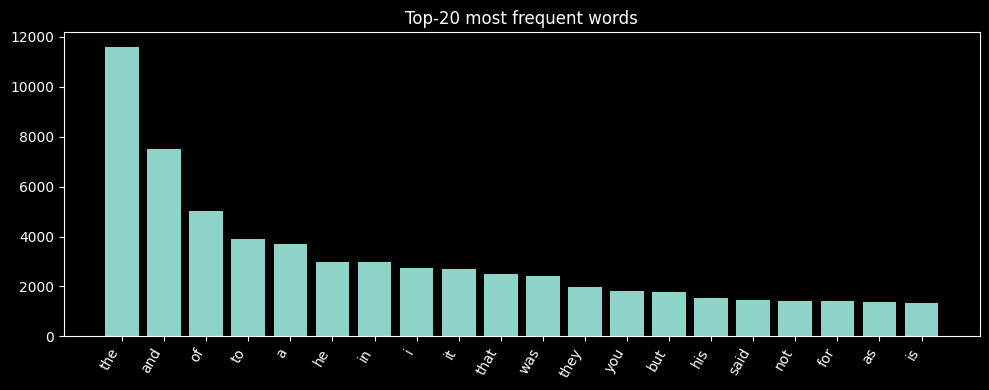

In [30]:
TOPN = 20  # поставь 10..30
top = freqs.most_common(TOPN)

words = [w for w, _ in top]
counts = [c for _, c in top]

plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.xticks(rotation=60, ha="right")
plt.title(f"Top-{TOPN} most frequent words")
plt.tight_layout()
plt.show()